<a href="https://colab.research.google.com/github/chibisova/study-tracker/blob/master/ai504_1_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 7: Convolutional Neural Networks

In this practice session, we will cover implementation of Convolutional Neural Networks (CNNs) using PyTorch library. Particulary, in part 1, we will see how to define and use convolutional, batch normalization, and dropout layer to build a simple CNNs to classify MNIST. In part 2, we will implement ResNet for CIFAR-10 classification task and see the effectiveness of residual connection.

## 0. Preliminary

Let's import required libraries and datasets. We will use MNIST and CIFAR-10 to train a simple CNNs and ResNet, respectively.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import MNIST, CIFAR10
from IPython.display import Image

In [2]:
# MNIST
mnist_train = MNIST("./", train=True, transform=transforms.ToTensor(), target_transform=None, download=True)
mnist_test = MNIST("./", train=False, transform=transforms.ToTensor(), target_transform=None, download=True)
mnist_train, mnist_val = torch.utils.data.random_split(mnist_train, [50000, 10000])

dataloaders = {}
dataloaders['train'] = DataLoader(mnist_train, batch_size=128, shuffle=True)
dataloaders['val'] = DataLoader(mnist_val, batch_size=128, shuffle=False)
dataloaders['test'] = DataLoader(mnist_test, batch_size=128, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 489kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.49MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.70MB/s]


### Using FashionMNIST

In [18]:
from torchvision.datasets import FashionMNIST
# FashionMNIST
fashion_mnist_train = FashionMNIST(root='./data', train=True, transform=transforms.ToTensor(), download=True)
fashion_mnist_test = FashionMNIST(root='./data', train=False, transform=transforms.ToTensor(), download=True)

# You can split the training set into training and validation sets if needed, similar to MNIST
fashion_mnist_train, fashion_mnist_val = torch.utils.data.random_split(fashion_mnist_train, [50000, 10000])

fashion_dataloaders = {}
fashion_dataloaders['train'] = DataLoader(fashion_mnist_train, batch_size=128, shuffle=True)
fashion_dataloaders['val'] = DataLoader(fashion_mnist_val, batch_size=128, shuffle=False)
fashion_dataloaders['test'] = DataLoader(fashion_mnist_test, batch_size=128, shuffle=False)

print("FashionMNIST data loaders created.")
print(f"Train dataset size: {len(fashion_dataloaders['train'].dataset)}")
print(f"Validation dataset size: {len(fashion_dataloaders['val'].dataset)}")
print(f"Test dataset size: {len(fashion_dataloaders['test'].dataset)}")

FashionMNIST data loaders created.
Train dataset size: 50000
Validation dataset size: 10000
Test dataset size: 10000


In case of CIFAR-10, we use conventional transforms and normalization.

For more example, please refer to
https://pytorch.org/vision/stable/auto_examples/plot_transforms.html#sphx-glr-auto-examples-plot-transforms-py



In [3]:
transforms_train = transforms.Compose([
  transforms.RandomCrop(32, padding=4),
  transforms.RandomHorizontalFlip(),
  transforms.ToTensor(),
  transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])
transforms_test = transforms.Compose([
  transforms.ToTensor(),
  transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

cifar_train = CIFAR10(root='./', train=True,
            download=True, transform=transforms_train)
cifar_test = CIFAR10(root='./', train=False,
             download=True, transform=transforms_test)
cifar_loader = {}
cifar_loader['train'] = DataLoader(cifar_train, batch_size=128,
                        shuffle=True, num_workers=4)
cifar_loader['test'] = DataLoader(cifar_test, batch_size=128,
                       shuffle=False, num_workers=4)

100%|██████████| 170M/170M [00:05<00:00, 31.8MB/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


## 1. Convolutional, Batch Norm and Dropout Layer Practice

### 1.1. Convolutional Layer

In PyTorch, 2-dimensional convolutional layer is given with the pytorch `torch.nn.Conv2d` package. In this section, we will learn basic usage of pytorch convolutional layer with some example codes and practices.

As in our lecture session, we should specify convolution with the number of channels of input and output, kernel size, the size of stride and padding. In Pytorch `torch.nn.Conv2d` class, those traits can be specified as class parameters. The detailed explanation and default values are available on below and the official sites (https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html)


* in_channels (int) – Number of channels in the input image

* out_channels (int) – Number of channels produced by the convolution

* kernel_size (int or tuple) – Size of the convolving kernel

* stride (int or tuple, optional) – Stride of the convolution. Default: 1

* padding (int or tuple, optional) – Zero-padding added to both sides of the input. Default: 0

Now, let's define our convolutional layer and practice. As in our lecture note, let's suppose we have 32x32-sized image with 3 channels.

In [ ]:
"""
Note: Since PyTorch Conv2d receives 4-dimensional input (i.e. a batch of image(s)),
we define input x with the first argument 1.
"""
x = torch.randn(1, 3, 32, 32)

Then, the number of input channel is 3, which is the same value with the input images' channel (the second argument of above `randn` method).

How about the number of output channel, kernel and stride size? Following the figure in our lecture note, we can easily see that the number of output channel should be 1. You can naively regard the kernel size as the spatial size of filter in the lecture note. Thus, the kernel size should be (5,5), and the stride size should be 1. In practice, since the spatial size of filter in in square form (i.e., width = height), we usually specifiy kernel size with only single integer (in our case 5).

In [ ]:
# Fill out the ?? of below
conv_layer = torch.nn.Conv2d(in_channels=3, out_channels=1, kernel_size=5, padding=0, stride=1)

In [ ]:
# You should check the output size of covolution layer is [1, 1, 28, 28].
conv_layer(x).size()

torch.Size([1, 1, 28, 28])

Also check the other example in the lecture note as below.
* Input volume: 3x32x32
* 10 5x5 filters with stride 1, pad 2

In [ ]:
# Fill out the ?? of below
x = torch.randn(1, 3, 32, 32)
conv_layer = torch.nn.Conv2d(in_channels=3, out_channels=10, kernel_size=5, padding=2, stride=1)
print(conv_layer(x).size())

torch.Size([1, 10, 32, 32])


### 1.2. BatchNorm and Dropout layer

In a similar manner, batch normalization and dropout layer also can be used from `torch.nn.BatchNorm2d` and `torch.nn.Dropout2d`.

In [ ]:
x = torch.randn(1, 3, 32, 32)

bn = torch.nn.BatchNorm2d(num_features=3)
print(bn(x).size()) # check batch norm does not change the size of input

dropout = torch.nn.Dropout2d(p=0.5) # dropout can specify probability of an element to be zeroed.
print(dropout(bn(x)).size()) # check dropout does not change the size of input

torch.Size([1, 3, 32, 32])
torch.Size([1, 3, 32, 32])


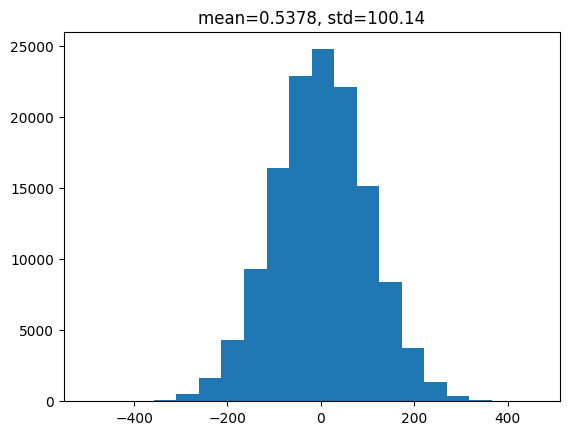

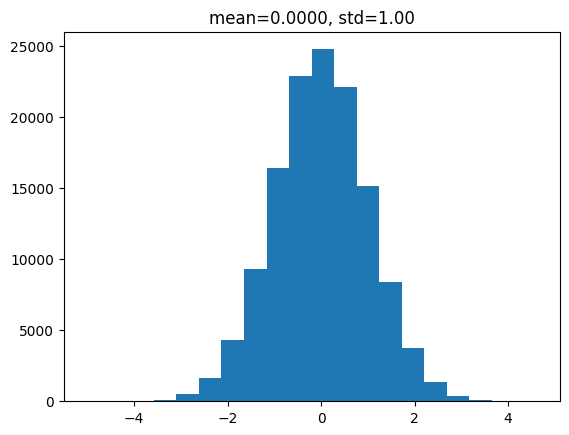

In [ ]:
"""
Provide some evidences for the implementation of BatchNorm & DropOut
"""
def show_evidence_plot_for_batch_norm():
    import torch
    import torch.nn as nn
    import matplotlib.pyplot as plt

    x = torch.randn(128, 3, 32, 32)
    x = x * 100  # amplify
    bn = nn.BatchNorm2d(num_features=3)
    assert x.size() == bn(x).size()

    x_c1 = x[:,0,:,:].flatten()
    bn_x_c1 = bn(x)[:,0,:,:].detach().flatten()

    plt.hist(x_c1, bins=20)
    plt.title(f"mean={x_c1.mean():.4f}, std={x_c1.std():.2f}")
    plt.show()

    plt.hist(bn_x_c1, bins=20)
    plt.title(f"mean={bn_x_c1.mean():.4f}, std={bn_x_c1.std():.2f}")
    plt.show()

show_evidence_plot_for_batch_norm()

### 1.3. Build a Simple Convolutional Neural Network

We can combine convolution layer, batch norm layer and activation function (e.g., ReLU) to construct a functional unit. In this case, we can use `torch.nn.Sequential` to define a block of sequential layers.

In [5]:
class Net(nn.Module):

    def __init__(self):
        super(Net, self).__init__()
        # 1 input image channel, 32 output channels, 7x7 square convolution, 1 stride
        self.layer1 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=7, padding=0, stride=1),
            nn.BatchNorm2d(num_features = 32),
            nn.ReLU(),
        )
        # 32 input image channel, 64 output channels, 7x7 square convolution, 1 stride
        self.layer2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=7, padding=0, stride=1),
            nn.BatchNorm2d(num_features = 64),
            nn.ReLU(),
        )

        # Calculation of features:
        # (N-F)/stride + 1
        # Input: 1x28x28
        # After layer1 (Conv(1->32, k=7, p=0, s=1)): (28-7)/1 + 1 = 22 -> 32x22x22
        # After layer2 (Conv(32->64, k=7, p=0, s=1)): (22-7)/1 + 1 = 16 -> 64x16x16
        # Flattened: 64 * 16 * 16 = 16384
        self.fc = nn.Linear(64*16*16, 10) # Fixed input features and output classes for MNIST (10 classes)

    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = torch.flatten(out, 1)
        out = self.fc(out)
        return out

In [6]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

net = Net().to(device)
optimizer = torch.optim.SGD(net.parameters(), lr=0.01)

cuda:0


In [7]:
criterion = torch.nn.CrossEntropyLoss()

In [19]:
import time

start_time = time.time()

for epoch in range(20):
    net.train() # Set the model to training mode
    train_loss = 0.0
    correct = 0.0
    total = 0.0

    for batch_idx, (x, y) in enumerate(fashion_dataloaders['train']):
        # x - images, y - labels
        x, y = x.to(device), y.to(device)
        out = net(x)
        loss = criterion(out, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        correct += (out.argmax(1) == y).float().sum().item()
        total += x.size(0)

    print(f"Epoch [{epoch+1}/20], Loss: {train_loss / (batch_idx+1):.4f}, Accuracy: {100. * correct / total:.2f}% ({time.time() - start_time:.2f}s elapsed)")

Epoch [1/20], Loss: 0.6710, Accuracy: 79.46% (9.56s elapsed)
Epoch [2/20], Loss: 0.3634, Accuracy: 86.88% (19.60s elapsed)
Epoch [3/20], Loss: 0.3087, Accuracy: 88.90% (28.83s elapsed)
Epoch [4/20], Loss: 0.2791, Accuracy: 89.98% (38.35s elapsed)
Epoch [5/20], Loss: 0.2543, Accuracy: 90.79% (47.91s elapsed)
Epoch [6/20], Loss: 0.2350, Accuracy: 91.40% (57.21s elapsed)
Epoch [7/20], Loss: 0.2184, Accuracy: 92.16% (66.35s elapsed)
Epoch [8/20], Loss: 0.2040, Accuracy: 92.68% (75.88s elapsed)
Epoch [9/20], Loss: 0.1907, Accuracy: 93.25% (85.33s elapsed)
Epoch [10/20], Loss: 0.1815, Accuracy: 93.53% (94.57s elapsed)
Epoch [11/20], Loss: 0.1675, Accuracy: 94.11% (103.81s elapsed)
Epoch [12/20], Loss: 0.1592, Accuracy: 94.43% (113.32s elapsed)
Epoch [13/20], Loss: 0.1502, Accuracy: 94.85% (122.76s elapsed)
Epoch [14/20], Loss: 0.1399, Accuracy: 95.28% (132.17s elapsed)
Epoch [15/20], Loss: 0.1329, Accuracy: 95.58% (141.39s elapsed)
Epoch [16/20], Loss: 0.1256, Accuracy: 95.81% (150.90s elaps

The `logits_test_set` tensor below contains the raw, unnormalized output scores for every image in  MNIST test set, as assignment describes.

In [20]:
all_logits = []
net.eval() # Set the model to evaluation mode
with torch.no_grad(): # Disable gradient calculations
    for x_test, y_test in fashion_dataloaders['test']:
        x_test = x_test.to(device)
        out_logits = net(x_test)
        all_logits.append(out_logits.cpu()) # Move to CPU and store

# Concatenate all batch logits into a single tensor
logits_test_set = torch.cat(all_logits, dim=0)

print(f"Shape of generated test logits: {logits_test_set.shape}")
# Display the first 5 rows of logits to see their structure
print("First 5 rows of test logits:")
print(logits_test_set[:5])

Shape of generated test logits: torch.Size([10000, 10])
First 5 rows of test logits:
tensor([[-4.2036e+00, -6.1110e+00, -6.3321e+00, -3.8989e+00, -3.2270e+00,
          5.5780e+00, -2.7130e+00,  6.5233e+00, -7.3475e-01,  1.5231e+01],
        [ 5.8609e+00, -7.7968e+00,  1.3392e+01, -2.6533e-01,  5.8866e+00,
         -9.2578e+00,  6.0485e+00, -5.3032e+00, -5.4435e+00, -5.2745e+00],
        [ 1.9407e+00,  1.3587e+01, -2.5190e+00, -1.4721e-02,  1.0828e+00,
         -1.6881e+00, -2.1346e+00, -5.6528e+00,  2.4968e-01, -5.4285e+00],
        [ 2.0948e-01,  1.5736e+01, -2.2635e+00,  3.9370e+00,  1.0973e+00,
         -5.2918e+00, -2.1603e+00, -6.6124e+00, -2.9988e+00, -2.3578e+00],
        [ 6.9174e+00, -3.4198e+00,  2.4788e+00,  8.5941e-01,  5.1107e+00,
         -6.2088e+00,  9.5567e+00, -7.2658e+00, -3.8611e+00, -5.0570e+00]])


Save logits in .npy file

In [21]:
import numpy as np

# Convert the PyTorch tensor to a NumPy array
logits_numpy = logits_test_set.numpy()

# Verify the shape
print(f"Shape of NumPy logits: {logits_numpy.shape}")

# Save the NumPy array to the specified file name
np.save('12345678.npy', logits_numpy)

print("Logits saved to studentID.npy")

Shape of NumPy logits: (10000, 10)
Logits saved to studentID.npy


In [ ]:
net.eval()
correct = 0.0
for x, y in dataloaders['test']:
    x, y = x.to(device), y.to(device)
    out = net(x)
    correct += (out.argmax(1) == y).float().sum().item()
print(100. * correct / len(dataloaders['test'].dataset))

99.08


## 2. CNN Architecture: ResNet

In this section, we will implement ResNet and see the effectiveness of residual connection in terms of test performance.

The overall structure of ResNet is like below.

* input(channel:3) -> (conv 3x3) -> (bn) -> (relu) -> output(channel:16)
* n Residual blocks: (16 channels -> 16 channels)
* n Residual blocks: (16 channels -> 32 channels)
* n Residual blocks: (32 channels -> 64 channels)
* global average pooling + fully connected layer

n can be chosen from {3,5,7,9,18} which of each corresponds to ResNet-20, 32, 44, 56, and 110, respectively.

### 2.1. Residual Block

Residual Block consists of 2 convolution layers with 3x3 size kernel and ReLU activation function. Let's implement `ResidualBlock` class below with 2 convolutional layers and residual connection.

In [23]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, down_sample=False):
        super(ResidualBlock, self).__init__()
        # stride = stride to change the shape
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                     stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        # stride = 1, cause we dont want to change the shape
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                             stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.down_sample = down_sample
        self.stride = stride
        self.in_channels = in_channels
        self.out_channels = out_channels

    def down_sampling(self, x):
        out = F.pad(x, (0, 0, 0, 0, 0, self.out_channels - self.in_channels))
        out = nn.MaxPool2d(2, stride=self.stride)(out)
        return out


    def forward(self, x):
        shortcut = x # this will be used to build residual connection.

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        #############################################
        # To match the inpute dimension to the iutput dimension
        #############################################
        if self.down_sample:
          shortcut = self.down_sampling(x)

        out += shortcut # residual connection
        out = self.relu(out)
        return out

`ResidualBlock` class which extends `torch.nn.Module`. `ResidualBlock` class receives `in_channels`, `out_channels`, `stride` and `down_sample`.

In ResNet, there are residual blocks that twice the output channel(16 to 32, 32 to 64). The `stride` argument for `ResidualBlock` is set to 2 in such residual blocks to down sample (reduce spatial dimension) while increasing channels.

However, the residual connection in the residual block can occur dimension mismatch since the output of other path (through convolutional layers) change the dimension of input with `stride=2`. Thus, residual block should support downsample through the residual connection in demand.

We support this feature in `down_sampling` method in `ResidualBlock` class. It conducts zero-padding to exapnd the channels and max-pooling to shrink spatial dimension through residual block. Using `down_sampling` in the middle of the `forward` method to handle `down_sample` condition to residual connection.

### 2.2. ResNet

Now implement `ResNet` class. Assume the `block` argument will be `ResidualBlock` we implemented above. Here are required implementation details.

* In `init` method, specifiy all details of convolution, batch norm layers.
* In `get_layers` method, set down_sample boolean variable according to the stride information. Then, define a list of residual blocks (`layer_list`). Make sure the down-sample only occurs at the first block in demand.

The overall structure of ResNet is like below.

* input(channel:3) -> (conv 3x3) -> (bn) -> (relu) -> output(channel:16)
* n Residual blocks: (16 channels -> 16 channels)
* n Residual blocks: (16 channels -> 32 channels)
* n Residual blocks: (32 channels -> 64 channels)
* global average pooling + fully connected layer

n can be chosen from {3,5,7,9,18} which of each corresponds to ResNet-20, 32, 44, 56, and 110, respectively.

In [34]:
class ResNet(nn.Module):
    def __init__(self, num_layers, block, num_classes=10):
        super(ResNet, self).__init__()
        self.num_layers = num_layers

        #input(channel:3) -> (conv 3x3) -> (bn) -> (relu) -> output(channel:16)
        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=16,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False)
        self.bn1 = nn.BatchNorm2d(num_features=16)
        self.relu = nn.ReLU(inplace=True)

        # feature map size = 16x32x32, keeps spatial dimension same -> s = 1
        self.layers_2n = self.get_layers(block, 16, 16, stride=1)

        # feature map size = 32x16x16, apply downsampling
        self.layers_4n = self.get_layers(block, 16, 32, stride=2)
        # With stride=2, the spatial dimensions are halved: 32 / 2 = 16.
        # Output: 32x16x16 (channels change from 16 to 32, spatial from 32x32 to 16x16)

        # feature map size = 64x8x8, apply downsampling
        self.layers_6n = self.get_layers(block, 32, 64, stride=2)
        # With stride=2, the spatial dimensions are halved: 16 / 2 = 8.
        # Output: 64x8x8 (channels change from 32 to 64, spatial from 32x32 to 8x8)

        # output layers
        # a kernel_size of 8 is used to average over the entire 8x8 region for rgb image.
        # changed to 7x7 for grayscale
        self.avg_pool = nn.AvgPool2d(7, stride=1)
        # This results in a 64x1x1 tensor ->
        self.fc_out = nn.Linear(64*1*1, num_classes)

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)


    def get_layers(self, block, in_channels, out_channels, stride):
        if stride == 2:
            down_sample = True
        else:
            down_sample = False

        layer_list = nn.ModuleList([block(in_channels, out_channels, stride, down_sample)])

        ##############################
        # Implement here: layer_list #
        ##############################

        # add num_layers
        for _ in range(self.num_layers -1 ):
            layer_list.append(block(out_channels, out_channels))


        return nn.Sequential(*layer_list)


    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.layers_2n(x)
        x = self.layers_4n(x)
        x = self.layers_6n(x)

        x = self.avg_pool(x)
        x = x.view(x.size(0), -1)
        x = self.fc_out(x)

        return x

In this practice we use resnet32 to train CIFAR-10.

In [35]:
def resnet18():
    block = ResidualBlock
    model = ResNet(3, block)
    return model
def resnet32():
    block = ResidualBlock
    model = ResNet(5, block)
    return model

By replacing `ResidualBlock` with plain `Block` (without residual connection), we can compare the effectiveness of residual connection.

In [36]:
class Block(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, down_sample=False):
        super(Block, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                     stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                             stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.stride = stride
        self.in_channels = in_channels
        self.out_channels = out_channels


    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        return out

In [37]:
def cnn18():
    block = Block
    model = ResNet(3, block)
    return model

def cnn32():
    block = Block
    model = ResNet(5, block)
    return model

### 2.3. Train

Training resnet is not different with other training schemes. We train 64000 batch steps with 128 batch size. The learning rate starts from 0.1 and is decayed at 32,000 and 48,000 step with 0.1 factor.

In [38]:
net = resnet18().to(device)
optimizer = torch.optim.SGD(net.parameters(), lr=0.1, momentum=0.9, weight_decay=1e-4)
decay_epoch = [32000, 48000]
step_lr_scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=decay_epoch, gamma=0.1)

In [39]:
import time
start_time = time.time()

net.train()

step = 0
epochs = 0
losses = []

#for epoch in range(85):

while step < 64000:

    train_loss = 0.0
    correct = 0.0
    total = 0.0

    for batch_idx, (x, y) in enumerate(fashion_dataloaders['train']):
        step += 1
        step_lr_scheduler.step()
        x, y = x.to(device), y.to(device)
        out = net(x)
        loss = criterion(out, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        correct += (out.argmax(1) == y).float().sum().item()
        total += x.size(0)
        train_loss += loss.item()

    losses.append(train_loss)
    epochs += 1

    print("Epoch[{:d} ({:d}/64000) ({:.4f}sec)] loss: {:.2f} acc: {:.2f}".format(epochs, step, time.time()-start_time, train_loss, 100.*correct/total))


/tmp/ipykernel_771/2002038414.py:18: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  step_lr_scheduler.step()


Epoch[1 (391/64000) (14.4486sec)] loss: 266.79 acc: 75.60
Epoch[2 (782/64000) (28.6198sec)] loss: 122.36 acc: 88.47
Epoch[3 (1173/64000) (43.3300sec)] loss: 98.13 acc: 90.74
Epoch[4 (1564/64000) (57.7765sec)] loss: 86.42 acc: 91.93
Epoch[5 (1955/64000) (72.1227sec)] loss: 78.87 acc: 92.72
Epoch[6 (2346/64000) (86.7283sec)] loss: 71.44 acc: 93.26
Epoch[7 (2737/64000) (101.2155sec)] loss: 67.59 acc: 93.61
Epoch[8 (3128/64000) (115.2720sec)] loss: 62.40 acc: 94.16
Epoch[9 (3519/64000) (129.8892sec)] loss: 57.82 acc: 94.56
Epoch[10 (3910/64000) (144.0542sec)] loss: 53.47 acc: 94.96
Epoch[11 (4301/64000) (158.2007sec)] loss: 51.71 acc: 95.18
Epoch[12 (4692/64000) (172.6270sec)] loss: 47.73 acc: 95.57
Epoch[13 (5083/64000) (188.5176sec)] loss: 44.87 acc: 95.78
Epoch[14 (5474/64000) (202.8341sec)] loss: 41.50 acc: 96.11
Epoch[15 (5865/64000) (218.2151sec)] loss: 40.19 acc: 96.19
Epoch[16 (6256/64000) (233.5503sec)] loss: 35.77 acc: 96.59
Epoch[17 (6647/64000) (247.6893sec)] loss: 35.48 acc: 9

KeyboardInterrupt: 

Plot train loss and calculate test performance.

In [40]:
import matplotlib
import matplotlib.pyplot as plt

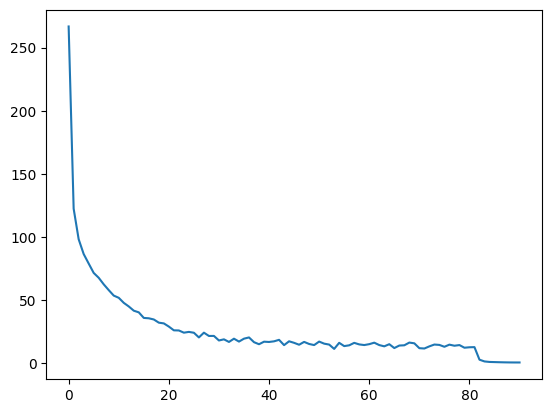

In [41]:
plt.plot(losses)

Save to .npy file:

In [42]:
all_logits = []
net.eval() # Set the model to evaluation mode
with torch.no_grad(): # Disable gradient calculations
    for x_test, y_test in fashion_dataloaders['test']:
        x_test = x_test.to(device)
        out_logits = net(x_test)
        all_logits.append(out_logits.cpu()) # Move to CPU and store

# Concatenate all batch logits into a single tensor
logits_test_set = torch.cat(all_logits, dim=0)

print(f"Shape of generated test logits: {logits_test_set.shape}")
# Display the first 5 rows of logits to see their structure
print("First 5 rows of test logits:")
print(logits_test_set[:5])

import numpy as np

# Convert the PyTorch tensor to a NumPy array
logits_numpy = logits_test_set.numpy()

# Verify the shape
print(f"Shape of NumPy logits: {logits_numpy.shape}")

# Save the NumPy array to the specified file name
np.save('12345679.npy', logits_numpy)

print("Logits saved to 12345679.npy")

Shape of generated test logits: torch.Size([10000, 10])
First 5 rows of test logits:
tensor([[-3.1763, -1.2030, -4.6709, -2.6386, -2.3325,  0.1740, -0.0275, -0.0405,
         -1.8949, 15.7446],
        [ 3.5557, -0.2073,  9.6601,  2.5609, -2.9266, -2.4468, -1.8227, -3.3864,
         -2.0359, -2.9433],
        [-1.1524, 10.8585, -1.3540,  0.5213, -0.8276, -2.1685, -2.6183, -2.4884,
         -0.1312, -0.5867],
        [-2.2128, 14.1170, -3.6701, -1.5452, -2.4656, -1.4334, -0.4040, -2.3427,
          1.1298, -1.1059],
        [ 7.4684, -4.5203, -4.2181, -2.4522,  1.1327, -2.1685, 12.3006, -1.7113,
         -3.7022, -2.1669]])
Shape of NumPy logits: (10000, 10)
Logits saved to 12345679.npy


Accuracy on test:

In [43]:
net.eval()
test_correct = 0.0
test_total = 0.0
for batch_idx, (x, y) in enumerate(fashion_dataloaders['test']):
    x, y = x.to(device), y.to(device)
    out = net(x)
    test_correct += (out.argmax(1) == y).float().sum().item()
    test_total += x.size(0)

print(test_correct/test_total * 100.)


93.32000000000001


### Visualize Model Predictions

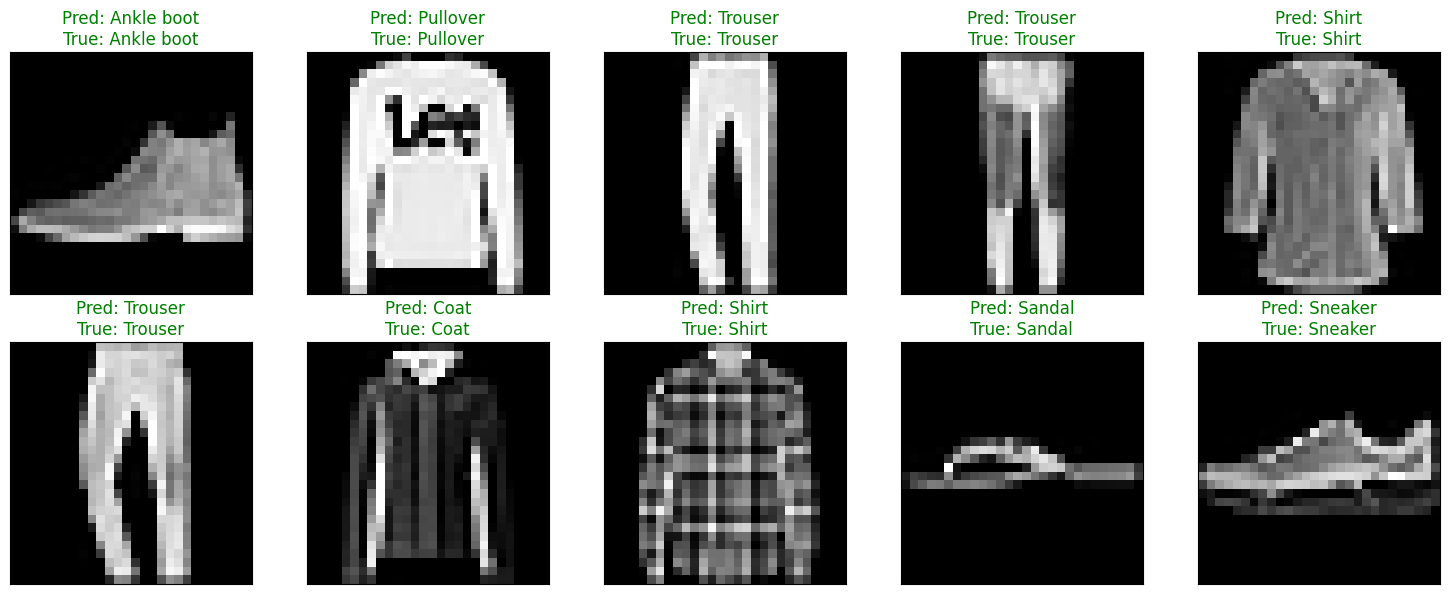

In [46]:
import matplotlib.pyplot as plt

def visualize_predictions(model, dataloader, device, num_images=10):
    model.eval() # Set the model to evaluation mode
    class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
                   'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

    # Get a batch of test data
    images, labels = next(iter(dataloader))
    images, labels = images.to(device), labels.to(device)

    with torch.no_grad():
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)

    # Plot images with predictions and ground truth
    fig = plt.figure(figsize=(15, 6))
    for i in range(min(num_images, len(images))):
        # Use integer division for the number of columns
        ax = fig.add_subplot(2, num_images // 2, i + 1, xticks=[], yticks=[])
        image = images[i].cpu().squeeze() # Remove channel dimension for grayscale image
        ax.imshow(image, cmap='gray')
        ax.set_title(f"Pred: {class_names[predicted[i]]}\nTrue: {class_names[labels[i]]}",
                     color=("green" if predicted[i] == labels[i] else "red"))
    plt.tight_layout()
    plt.show()

# Call the function to visualize predictions for the 'net' model trained on FashionMNIST
visualize_predictions(net, fashion_dataloaders['test'], device, num_images=10)


### Reference
* https://tutorials.pytorch.kr/beginner/blitz/neural_networks_tutorial.html
* https://github.com/dnddnjs/pytorch-cifar10/blob/enas/resnet/model.py
* https://icml.cc/2016/tutorials/icml2016_tutorial_deep_residual_networks_kaiminghe.pdf

# Test:

In [4]:
from project1_test_script import evaluate

In [45]:
evaluate('12345679.npy')

Using device: cuda
Test dataset size: 10000
12345679 - Accuracy: 93.32%
